# Manuscript triplet-loss visualization

This notebook plots the smooth triplet-loss surface used by the publication BO-VAE implementation. It imports `TripletLossTorch` from the maintained package, so the visualization and DML retraining use the same elementwise calculation.

Run the notebook from the publication repository root after installing the package dependencies, or set `PYTHONPATH=BOVAE/src`.


In [1]:
import matplotlib.pyplot as plt
import torch

from bo_vae_sdr.vae.metrics import TripletLossTorch

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


The effective visualization settings are unchanged: the positive embedding and normalized-objective distances are `0.6` and `0.1`; the triplet threshold and smoothing parameter are `0.25` and `0.05`; and the negative-distance axes contain 100 points over `[0, 2]` and `[0, 1]`.


In [2]:
positive_embedding_distance = 0.6
positive_target_distance = 0.1
threshold = 0.25
eta = 0.05
num_grid_points = 100

negative_embedding_distances = torch.linspace(
    0.0, 2.0, num_grid_points, device=device
)
negative_target_distances = torch.linspace(
    0.0, 1.0, num_grid_points, device=device
)
negative_embedding_grid, negative_target_grid = torch.meshgrid(
    negative_embedding_distances,
    negative_target_distances,
    indexing="ij",
)

metric_loss = TripletLossTorch(threshold=threshold, eta=eta)
loss = metric_loss.triplet_loss_values(
    positive_embedding_distances=torch.full_like(
        negative_embedding_grid, positive_embedding_distance
    ),
    negative_embedding_distances=negative_embedding_grid,
    positive_target_distances=torch.full_like(
        negative_target_grid, positive_target_distance
    ),
    negative_target_distances=negative_target_grid,
).detach().cpu().numpy()


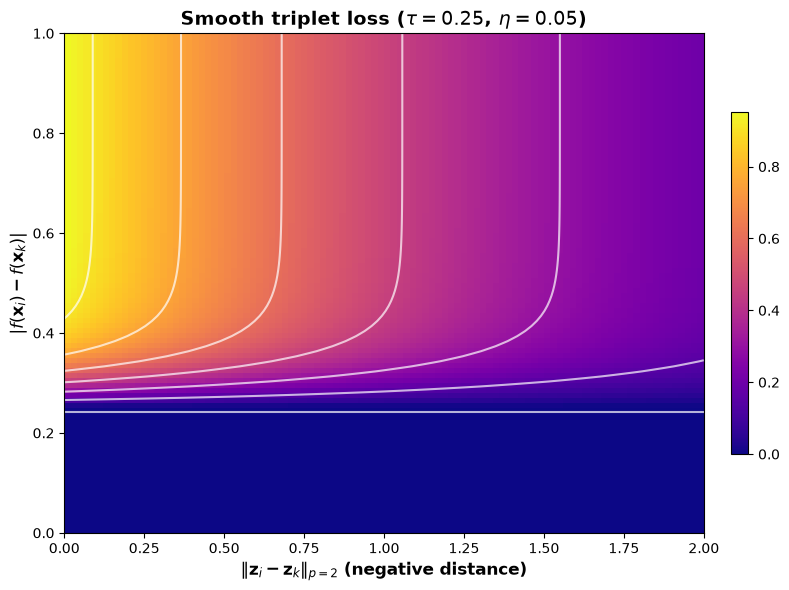

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    loss.T,
    origin="lower",
    cmap="plasma",
    extent=[0, 2, 0, 1],
    aspect="auto",
)
ax.contour(
    loss.T,
    extent=[0, 2, 0, 1],
    colors="white",
    alpha=0.7,
)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
ax.set_xlabel(
    r"$\|\mathbf{z}_i - \mathbf{z}_k\|_{p=2}$ (negative distance)",
    fontsize=12,
    weight="bold",
)
ax.set_ylabel(
    r"$|f(\mathbf{x}_i) - f(\mathbf{x}_k)|$",
    fontsize=12,
    weight="bold",
)
ax.set_title(
    rf"Smooth triplet loss ($\tau={threshold}$, $\eta={eta}$)",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()
